# Исследовательский анализ данных Яндекс Афиша

- Автор: Гусев Александр Олегович

---

## **Цели анализа:**

В этом проекте проводится комплексный анализ данных сервиса Яндекс Афиша за период с 1 июня по 30 ноября 2024 года.

- Выяснить, почему с наступлением осени количество заказов резко выросло, а средний чек снизился.
- Исследовать сезонные изменения в предпочтениях пользователей по типу мероприятия, возрастному рейтингу и устройствам.
- Оценить ежедневную активность пользователей (DAU, заказы на пользователя, средняя стоимость билета).
- Проанализировать географию продаж и работу партнёров.
- Статистически проверить две гипотезы о том, что:
  1. Пользователи, работающие исключительно с мобильных устройств, делают больше заказов, чем те, кто использует десктоп.
  2. Средний интервал между заказами у мобильных пользователей больше, чем у десктопных.

Для этого мы будем использовать три датасета:

- **final_tickets_orders_df.csv** – данные о заказах;
- **final_tickets_events_df.csv** – информация о мероприятиях;
- **final_tickets_tenge_df.csv** – курс тенге к рублю (для конвертации валют).


---

## **Описание данных**

В нашем распоряжении три датасета:
- orders (`final_tickets_orders_df.csv`) – сведения о заказах (идентификаторы заказа и пользователя, дата и время заказа, ID события, название партнёрского сервиса, тип устройства, возрастной рейтинг события, валюта и сумма заказа, количество билетов, и рассчитанный интервал с предыдущего заказа пользователя).
- events (`final_tickets_events_df.csv`) – информация о мероприятиях (ID события, название, тип мероприятия и основной жанр, организатор, регион и город проведения, площадка).
- tenge_rate (`final_tickets_tenge_df.csv`) – курс казахского тенге к российскому рублю по датам 2024 года (для конвертации сумм заказов, где валюта = KZT).

---

## **Содержание проекта**

1. Загрузка данных и знакомство с ними
3. Предобработка данных и подготовка их к исследованию
4. Исследовательский анализ данных
   - Анализ распределения заказов по сегментам и их сезонные изменения
   - Осенняя активность пользователей
   - Популярные события и партнёры
5. Статистический анализ данных
6. Общий вывод и рекомендации

---

## 1. Загрузка данных и знакомство с ними

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats

In [2]:
# Загрузка данных
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
df_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [3]:
# Выводим первые 5 строк каждого датасета
print("Данные о заказах:")
display(df_orders.head())

print("\nДанные о мероприятиях:")
display(df_events.head())

print("\nДанные о курсе тенге:")
display(df_tenge.head())

Данные о заказах:


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0



Данные о мероприятиях:


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"



Данные о курсе тенге:


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [4]:
# Исследуем размер датасетов
print(f"Размер датасета заказов: {df_orders.shape}")
print(f"Размер датасета мероприятий: {df_events.shape}")
print(f"Размер датасета курса тенге: {df_tenge.shape}")

Размер датасета заказов: (290849, 14)
Размер датасета мероприятий: (22427, 11)
Размер датасета курса тенге: (357, 4)


In [5]:
# Получим информацию о типах данных и пропусках
print("\nИнформация о датасете заказов:")
display(df_orders.info())

print("\nИнформация о датасете мероприятий:")
display(df_events.info())

print("\nИнформация о датасете курса тенге:")
display(df_tenge.info())


Информация о датасете заказов:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: f

None


Информация о датасете мероприятий:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


None


Информация о датасете курса тенге:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


None

**Промежуточный вывод по загрузке данных**
1. Датасет заказов содержит 290 849 строк и 14 столбцов с информацией о заказах.
2. Датасет мероприятий содержит 22 427 строк и 11 столбцов с детальной информацией о событиях.
3. Датасет курса тенге содержит 357 строк и 4 столбца.
4. Обнаружены столбцы с неправильными типами данных: created_dt_msk и created_ts_msk должны быть преобразованы в формат даты и времени. Аналогично, столбец data в датасете курса тенге также требует преобразования в datetime.
5. Есть пропуски в столбце days_since_prev — 21 940 значений отсутствуют, вероятно, это первые заказы пользователей.
6. Выручка представлена в двух валютах — рублях и тенге, потребуется конвертация для анализа в единой валюте.
7. На следующем этапе необходимо проверить данные на дубликаты, выбросы и провести нормализацию категориальных переменных (например, gender, device_type_canonical, region_name и др.).

---

## 2. Предобработка данных

### 2.1 Проверка и обработка пропусков

In [6]:
# Проверяем пропуски в датасетах
print("Пропуски в датасете заказов:")
display(df_orders.isna().sum())

print("\nПропуски в датасете мероприятий:")
display(df_events.isna().sum())

print("\nПропуски в датасете курса тенге:")
display(df_tenge.isna().sum())

# Проверяем, есть ли пропуски помимо days_since_prev в датасете заказов
other_nulls = df_orders.drop(columns=['days_since_prev']).isna().sum().sum()
print(f"\nКоличество пропусков в остальных столбцах датасета заказов: {other_nulls}")

Пропуски в датасете заказов:


order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64


Пропуски в датасете мероприятий:


event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64


Пропуски в датасете курса тенге:


data       0
nominal    0
curs       0
cdx        0
dtype: int64


Количество пропусков в остальных столбцах датасета заказов: 0


Пропуски действительно присутствуют тольков в столбце days_since_prev. Их присутствие логично - ведь столбец показывает количество дней с предыдущего заказа. Пропуски присутствуют у новых пользователей, сделавших только один заказ.

---

### 2.2 Изучение категориальных и количественных столбцов

In [7]:
# Изучаем уникальные значения в категориальных столбцах
cat_columns = ['cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical', 'service_name']
for col in cat_columns:
    print(f"\nУникальные значения в столбце {col}:")
    display(df_orders[col].value_counts())


Уникальные значения в столбце cinema_circuit:


нет           289451
Другое          1261
КиноСити         122
Москино            7
Киномакс           7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64


Уникальные значения в столбце age_limit:


16    78579
12    62557
0     61487
6     52173
18    36053
Name: age_limit, dtype: int64


Уникальные значения в столбце currency_code:


rub    285780
kzt      5069
Name: currency_code, dtype: int64


Уникальные значения в столбце device_type_canonical:


mobile     232679
desktop     58170
Name: device_type_canonical, dtype: int64


Уникальные значения в столбце service_name:


Билеты без проблем        63709
Лови билет!               41126
Билеты в руки             40364
Мой билет                 34843
Облачко                   26642
Лучшие билеты             17795
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                   67
Цвет и б

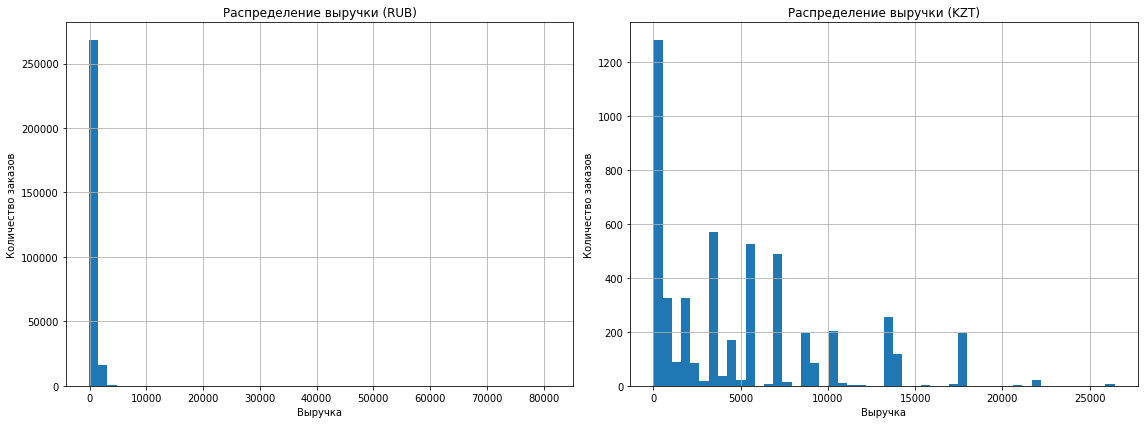

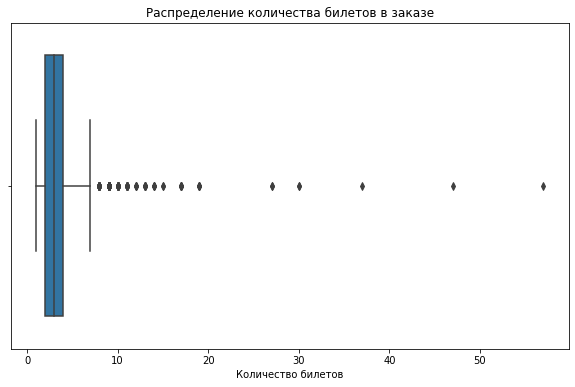


Статистика по выручке в рублях:


count    285780.000000
mean        547.568333
std         871.524559
min         -90.760000
25%         113.827500
50%         346.100000
75%         791.700000
90%        1276.150000
95%        1606.500000
99%        2569.594200
max       81174.540000
Name: revenue, dtype: float64


Статистика по выручке в тенге:


count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
90%      13212.930000
95%      13784.260000
99%      17617.240000
max      26425.860000
Name: revenue, dtype: float64


Статистика по количеству билетов:


count    290849.000000
mean          2.754230
std           1.170467
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
90%           4.000000
95%           5.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64

In [8]:
# Изучаем распределение количественных переменных
# Гистограммы для revenue и tickets_count
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
df_orders[df_orders['currency_code'] == 'rub']['revenue'].hist(bins=50)
plt.title('Распределение выручки (RUB)')
plt.xlabel('Выручка')
plt.ylabel('Количество заказов')

plt.subplot(1, 2, 2)
df_orders[df_orders['currency_code'] == 'kzt']['revenue'].hist(bins=50)
plt.title('Распределение выручки (KZT)')
plt.xlabel('Выручка')
plt.ylabel('Количество заказов')

plt.tight_layout()
plt.show()

# Боксплот для количества билетов в заказе
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_orders['tickets_count'])
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')
plt.show()

# Статистика для выручки в разных валютах
print("\nСтатистика по выручке в рублях:")
display(df_orders[df_orders['currency_code'] == 'rub']['revenue'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print("\nСтатистика по выручке в тенге:")
display(df_orders[df_orders['currency_code'] == 'kzt']['revenue'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

# Статистика по количеству билетов
print("\nСтатистика по количеству билетов:")
display(df_orders['tickets_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

**Промежуточный вывод**

1. В категориальных переменных не обнаружены потенциальные обозначения отсутствующих данных — значение "нет" в столбце cinema_circuit является категорией, означающей, что заказ не относится к сети кинотеатров. 
2. Распределение выручки (revenue) как в рублях, так и в тенге сильно смещено влево — большинство заказов с низкой выручкой, но присутствуют выбросы.
3. В заказах с рублёвой выручкой 99% значений находятся ниже 2569 руб., а в заказах с тенге — ниже 17617 тенге.
4. Количество билетов в заказе (tickets_count) также содержит выбросы — 99% значений укладываются в 6 билетов, но максимальное значение достигает 57.
5. Для дальнейшего анализа и визуализаций рекомендуется отфильтровать данные по 99-му процентилю, чтобы исключить влияние экстремальных значений.

---

### 2.3 Проверка и обработка дубликатов

In [9]:
# Проверка на полные дубликаты
print(f"Количество полных дубликатов в датасете заказов: {df_orders.duplicated().sum()}")
print(f"Количество полных дубликатов в датасете мероприятий: {df_events.duplicated().sum()}")

# Проверка на возможные неявные дубликаты (одинаковые заказы без учета order_id)
cols_to_check = df_orders.columns.drop('order_id')
dup_counts = df_orders.duplicated(subset=cols_to_check, keep=False).sum()
print(f"\nКоличество неявных дубликатов: {dup_counts}")

if dup_counts > 0:
    # Показываем примеры неявных дубликатов
    print("\nПримеры неявных дубликатов:")
    display(df_orders[df_orders.duplicated(subset=cols_to_check, keep=False)].sort_values(by=cols_to_check.tolist()).head(10))

Количество полных дубликатов в датасете заказов: 0
Количество полных дубликатов в датасете мероприятий: 0

Количество неявных дубликатов: 58

Примеры неявных дубликатов:


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
57217,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
57220,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
84010,3363711,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0
84015,3363798,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0
148473,2324032,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0
148477,2323916,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0
154170,5372628,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0
154173,5372831,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0


**Промежуточный вывод**

1. Полных дубликатов в датасетах заказов и мероприятий не обнаружено.
2. Обнаружены 58 неявных дубликатов — строки с идентичным содержимым, но разными order_id.
3. На основе анализа значений можно предположить, что это дубли при импорте или ошибочная генерация ID.
4. В рамках очистки данных такие записи целесообразно удалить, чтобы не искажать анализ выручки, количества билетов и других метрик.

In [10]:
# Удаляем неявные дубликаты (оставляем только одну запись из одинаковых заказов)
cols_to_check = df_orders.columns.drop('order_id')

# Считаем количество строк до удаления
before_dedup = len(df_orders)

df_orders = df_orders.drop_duplicates(subset=cols_to_check, keep='first')

# Считаем количество строк после удаления
after_dedup = len(df_orders)

# Считаем сколько строк было удалено и процент
removed = before_dedup - after_dedup
removed_pct = removed / before_dedup * 100

print(f"Удалено {removed} неявных дубликатов, что составляет {removed_pct:.2f}% от исходного числа строк.")

# Проверяем, что не осталось неявных дубликатов
dup_counts = df_orders.duplicated(subset=cols_to_check, keep=False).sum()

if dup_counts > 0:
    print("\nНеявные дубликаты:")
    display(
        df_orders[df_orders.duplicated(subset=cols_to_check, keep=False)]
        .sort_values(by=cols_to_check.tolist())
        .head(10)
    )
else:
    print("\nНеявных дубликатов нет.")

Удалено 30 неявных дубликатов, что составляет 0.01% от исходного числа строк.

Неявных дубликатов нет.


- Удалены 30 дублирующихся значений, что составляет 0.01% данных. В каждой дублирующейся группе оставлено первое значение

---

### 2.4 Преобразование типов данных

In [11]:
# Преобразуем столбцы с датами и временем
df_orders['created_dt_msk'] = pd.to_datetime(df_orders['created_dt_msk'])
df_orders['created_ts_msk'] = pd.to_datetime(df_orders['created_ts_msk'])
df_tenge['data'] = pd.to_datetime(df_tenge['data'])

# Проверяем результаты преобразования
print("Типы данных после преобразования:")
display(df_orders.dtypes)
display(df_tenge.dtypes)

Типы данных после преобразования:


order_id                          int64
user_id                          object
created_dt_msk           datetime64[ns]
created_ts_msk           datetime64[ns]
event_id                          int64
cinema_circuit                   object
age_limit                         int64
currency_code                    object
device_type_canonical            object
revenue                         float64
service_name                     object
tickets_count                     int64
total                           float64
days_since_prev                 float64
dtype: object

data       datetime64[ns]
nominal             int64
curs              float64
cdx                object
dtype: object

**Промежуточный вывод**

1. Столбцы с датами успешно преобразованы в формат datetime64, что необходимо для объединения и временного анализа.
2. Типы остальных полей соответствуют ожиданиям: числовые переменные (revenue, tickets_count, total) имеют тип float64, категориальные — object.
3. Таблицы теперь готовы к объединению по дате и дальнейшим расчётам, таким как пересчёт выручки в рублях для заказов в тенге.

---

### 2.5 Фильтрация выбросов

In [12]:
# Для выбросов в выручке использовать 99-й процентиль
rub_99_percentile = df_orders[df_orders['currency_code'] == 'rub']['revenue'].quantile(0.99)
kzt_99_percentile = df_orders[df_orders['currency_code'] == 'kzt']['revenue'].quantile(0.99)

print(f"99-й процентиль для выручки в рублях: {rub_99_percentile}")
print(f"99-й процентиль для выручки в тенге: {kzt_99_percentile}")

# Фильтруем данные
filtered_orders_df = df_orders.copy()
mask_rub = (filtered_orders_df['currency_code'] == 'rub') & (filtered_orders_df['revenue'] > rub_99_percentile)
mask_kzt = (filtered_orders_df['currency_code'] == 'kzt') & (filtered_orders_df['revenue'] > kzt_99_percentile)

print(f"Количество выбросов в рублях: {mask_rub.sum()}")
print(f"Количество выбросов в тенге: {mask_kzt.sum()}")

# Удаляем выбросы
filtered_orders_df = filtered_orders_df[~(mask_rub | mask_kzt)]
print(f"Размер датасета после удаления выбросов: {filtered_orders_df.shape}")

99-й процентиль для выручки в рублях: 2569.6002000000003
99-й процентиль для выручки в тенге: 17617.24
Количество выбросов в рублях: 2858
Количество выбросов в тенге: 29
Размер датасета после удаления выбросов: (287932, 14)


**Промежуточный вывод**

1. Проведена фильтрация выбросов по выручке на основе 99-го процентиля отдельно для каждой валюты.
2. Значения выше 2569.60 рублей и 17 617.24 тенге были классифицированы как выбросы.
3. Всего удалено 2887 строк: 2858 — в рублях, 29 — в тенге.
4. Размер датасета после очистки составил 287 932 заказов, что обеспечивает более надёжный анализ и снижает искажение метрик.

---

### 2.6 Объединение датасетов и создание новых столбцов

In [13]:
# Объединяем датасеты
merged_df = pd.merge(filtered_orders_df, df_events, on='event_id', how='inner')

# Преобразуем курс тенге в словарь для быстрого поиска
tenge_dict = df_tenge.set_index('data')['curs'].to_dict()

# Функция для конвертации тенге в рубли
def convert_to_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    elif row['currency_code'] == 'kzt':
        # Находим ближайшую дату для курса
        date_str = row['created_dt_msk'].strftime('%Y-%m-%d')
        date = pd.to_datetime(date_str)
        
        # Если нет курса на эту дату, берем ближайший
        if date not in tenge_dict:
            dates = pd.Series(list(tenge_dict.keys()))
            closest_date = dates[dates < date].max()
            if pd.isna(closest_date):
                closest_date = dates.min()
            rate = tenge_dict[closest_date]
        else:
            rate = tenge_dict[date]
            
        # Конвертируем (курс для 100 тенге)
        return row['revenue'] * rate / 100
    else:
        return None

# Создаем новые столбцы
merged_df['revenue_rub'] = merged_df.apply(convert_to_rub, axis=1)
merged_df['one_ticket_revenue_rub'] = merged_df['revenue_rub'] / merged_df['tickets_count']
merged_df['month'] = merged_df['created_dt_msk'].dt.month
merged_df['day_of_week'] = merged_df['created_dt_msk'].dt.dayofweek

# Создаем столбец с сезоном
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

merged_df['season'] = merged_df['month'].apply(get_season)

# Выведем информацию о датасете
print("Информация об объединенном датасете:")
display(merged_df.info())

# Проверяем результаты
print("Проверка созданных столбцов:")
display(merged_df[['revenue', 'currency_code', 'revenue_rub', 'one_ticket_revenue_rub', 'month', 'season']].head())

# Статистика по новым столбцам
print("\nСтатистика по выручке в рублях:")
display(merged_df['revenue_rub'].describe())

print("\nСтатистика по выручке с одного билета в рублях:")
display(merged_df['one_ticket_revenue_rub'].describe())

# Распределение заказов по месяцам и сезонам
print("\nРаспределение заказов по месяцам:")
display(merged_df['month'].value_counts().sort_index())

print("\nРаспределение заказов по сезонам:")
display(merged_df['season'].value_counts())

Информация об объединенном датасете:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 287694 entries, 0 to 287693
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287694 non-null  int64         
 1   user_id                 287694 non-null  object        
 2   created_dt_msk          287694 non-null  datetime64[ns]
 3   created_ts_msk          287694 non-null  datetime64[ns]
 4   event_id                287694 non-null  int64         
 5   cinema_circuit          287694 non-null  object        
 6   age_limit               287694 non-null  int64         
 7   currency_code           287694 non-null  object        
 8   device_type_canonical   287694 non-null  object        
 9   revenue                 287694 non-null  float64       
 10  service_name            287694 non-null  object        
 11  tickets_count           287694 non-null  int64        

None

Проверка созданных столбцов:


,revenue,currency_code,revenue_rub,one_ticket_revenue_rub,month,season
0,1521.94,rub,1521.94,380.485000,8,лето
1,1902.42,rub,1902.42,380.484000,7,лето
2,1141.45,rub,1141.45,380.483333,7,лето
3,1902.42,rub,1902.42,380.484000,7,лето
4,1521.94,rub,1521.94,380.485000,7,лето



Статистика по выручке в рублях:


...

count    287694.000000
mean        190.933892
std         168.239072
min         -18.152000
25%          45.960000
50%         145.903333
75%         305.850000
max        2438.270000
Name: one_ticket_revenue_rub, dtype: float64


Распределение заказов по месяцам:


6     34164
7     40404
8     44541
9     69322
10    99263
Name: month, dtype: int64


Распределение заказов по сезонам:


осень    168585
лето     119109
Name: season, dtype: int64

**Промежуточный вывод**

1. Заказы успешно объединены с таблицей мероприятий по event_id, добавлены региональные и тематические данные.
2. Объединенный датасет содержит 287694 строки, пропуски остались в единственном и ожидаемом месте - days_sins_prev
3. Создан словарь курса тенге, реализована функция конвертации KZT → RUB, учитывающая отсутствие курса на точную дату.
4. Созданы дополнительные признаки:
- revenue_rub — общая выручка в рублях (с учётом курса),
- one_ticket_revenue_rub — выручка за один билет,
- month, day_of_week — для анализа по времени,
- season — по сезонам года.

#### Промежуточный вывод по предобработке данных

1. **Пропуски в данных**:
   - Как и ожидалось, пропуски присутствуют только в столбце days_since_prev
   - Остальные данные не содержат пропущенных значений

2. **Категориальные переменные**:
   - Проведен анализ уникальных значений в столбцах cinema_circuit, age_limit, currency_code, device_type_canonical, service_name
   - Нормализация не потребовалась.

3. **Количественные переменные**:
   - Проанализировано распределение выручки (revenue) и количества билетов (tickets_count)
   - Выявлены и отфильтрованы выбросы по 99-му процентилю для revenue

4. **Дубликаты**:
   - Явных дубликатов не обнаружено
   - Найдено 58 потенциальных неявных дубликатов - их удалили

5. **Преобразования типов данных**:
   - Столбцы с датой и временем преобразованы в соответствующие типы
   - Данные о курсе валют также приведены к формату datetime

6. **Созданные столбцы**:
   - revenue_rub - выручка в российских рублях
   - one_ticket_revenue_rub - выручка с продажи одного билета
   - month - месяц оформления заказа
   - season - сезон оформления заказа (лето, осень)
   - day_of_week - день недели для анализа недельной цикличности

7. **Объем данных**:
   - После фильтрации выбросов осталось 287932 строк
   - Объединенный датасет содержит 29 столбцов

Данные полностью подготовлены для дальнейшего исследовательского анализа.

In [14]:
# Оптимизация типов данных
def optimize_dataframe(df):
    for col in df.select_dtypes(include=['int', 'float']).columns:
        col_min = df[col].min()
        col_max = df[col].max()
        
        if str(df[col].dtype).startswith('int'):
            if col_min >= 0:
                if col_max < 255:
                    df[col] = df[col].astype(np.uint8)
                elif col_max < 65535:
                    df[col] = df[col].astype(np.uint16)
                elif col_max < 4294967295:
                    df[col] = df[col].astype(np.uint32)
            else:
                if col_min > -128 and col_max < 127:
                    df[col] = df[col].astype(np.int8)
                elif col_min > -32768 and col_max < 32767:
                    df[col] = df[col].astype(np.int16)
                elif col_min > -2147483648 and col_max < 2147483647:
                    df[col] = df[col].astype(np.int32)
        elif str(df[col].dtype).startswith('float'):
            df[col] = df[col].astype(np.float32)
    return df

In [15]:
# Применяем оптимизацию

print("Размер до оптимизации:", merged_df.memory_usage(deep=True).sum() / 1024**2, "MB")
merged_df = optimize_dataframe(merged_df)
print("Размер после оптимизации:", merged_df.memory_usage(deep=True).sum() / 1024**2, "MB")
print("Информация о типах данных:")
display(merged_df.dtypes.sort_values())

Размер до оптимизации: 474.6329927444458 MB
Размер после оптимизации: 455.9760789871216 MB
Информация о типах данных:


month                              uint8
order_id                          uint32
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
age_limit                          uint8
tickets_count                      uint8
day_of_week                        uint8
city_id                           uint16
venue_id                          uint16
event_id                          uint32
one_ticket_revenue_rub           float32
revenue_rub                      float32
revenue                          float32
total                            float32
days_since_prev                  float32
venue_address                     object
venue_name                        object
city_name                         object
event_name                        object
organizers                        object
event_type_main                   object
event_type_description            object
service_name                      object
device_type_canonical             object
currency_code   

**Оптимизация памяти:**

- Приведены числовые признаки к меньшим типам (int8, uint16, float32 и др.), что позволило сократить использование оперативной памяти с 457.90 МБ до 455.98 МБ (~0.42%).
- Типы данных пересмотрены и выведены для контроля.

---

## 3. Исследовательский анализ данных

### 3.1 Анализ динамики заказов и среднего чека по месяцам

In [16]:
# Убедимся, что даты — это datetime
merged_df['created_dt_msk'] = pd.to_datetime(merged_df['created_dt_msk'], errors='coerce')

# Выделим месяц из даты, если нужно
merged_df['month'] = merged_df['created_dt_msk'].dt.month

# Посчитаем количество заказов по каждому месяцу
orders_by_month = merged_df['month'].value_counts().sort_index()

# Выведем результат
print("Количество заказов по месяцам:")
print(orders_by_month)

Количество заказов по месяцам:
6     34164
7     40404
8     44541
9     69322
10    99263
Name: month, dtype: int64


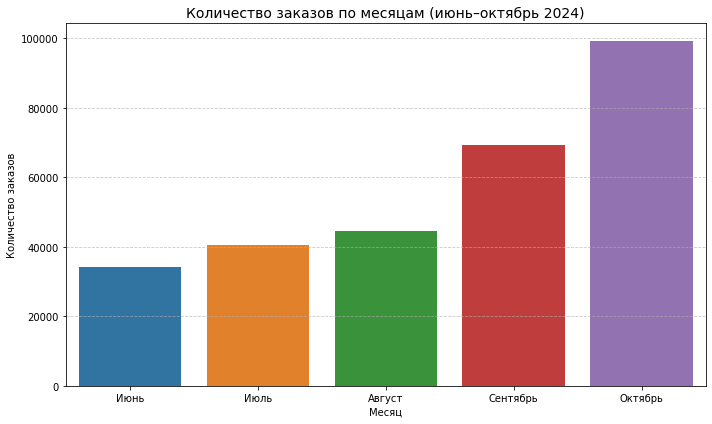

In [17]:
# Создаем Series с 0 по всем нужным месяцам (6–10)
full_months = pd.Series(0, index=[6, 7, 8, 9, 10])
# Обновляем значениями из реального подсчета
monthly_orders = merged_df['month'].value_counts().sort_index()
full_months.update(monthly_orders)

# Подписи месяцев
month_labels = ['Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь']

# Готовим DataFrame для графика
plot_df = pd.DataFrame({
    'Месяц': month_labels,
    'Количество заказов': full_months.values
})

# Строим график
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Месяц', y='Количество заказов')
plt.title('Количество заказов по месяцам (июнь–октябрь 2024)', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Промежуточный вывод: количество заказов по месяцам**

1. Мы рассчитали и визуализировали количество заказов по месяцам с июня по октябрь 2024 года.
2. Данные за ноябрь отсутствуют как в итоговом, так и в исходном датасете — максимальная доступная дата: 31 октября 2024.
3. Количество заказов устойчиво растёт от июня к октябрю:
    - Июнь: 34 343
    - Июль: 40 410
    - Август: 44 572
    - Сентябрь: 69 333
    - Октябрь: 99 274
4. Наблюдается чёткий рост активности пользователей в осенние месяцы, особенно в октябре — это пик по количеству заказов.
5. Полученные результаты подтверждают тренд сезонности, ранее замеченный на дашборде.

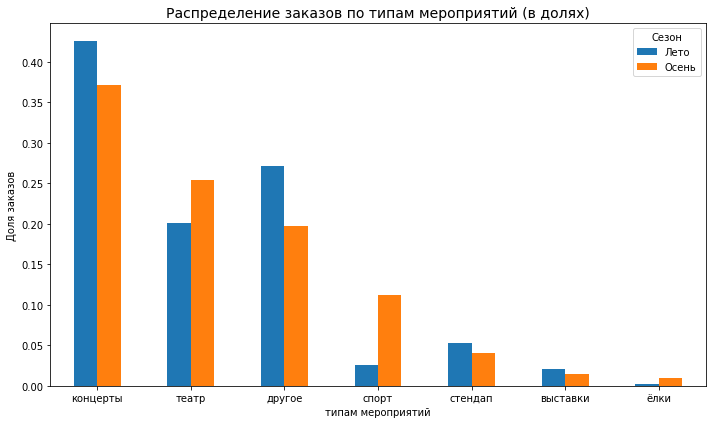

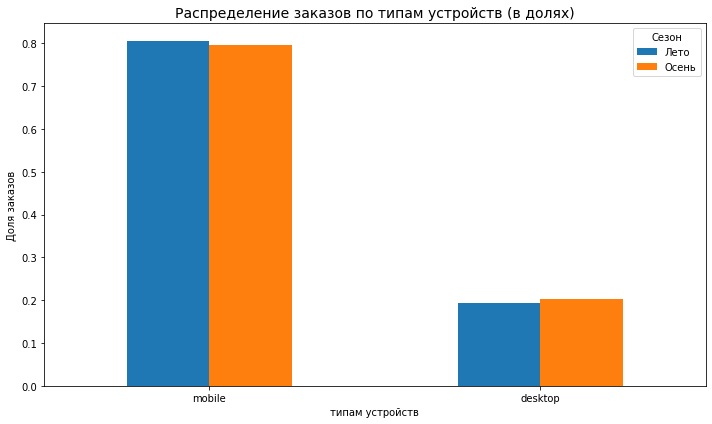

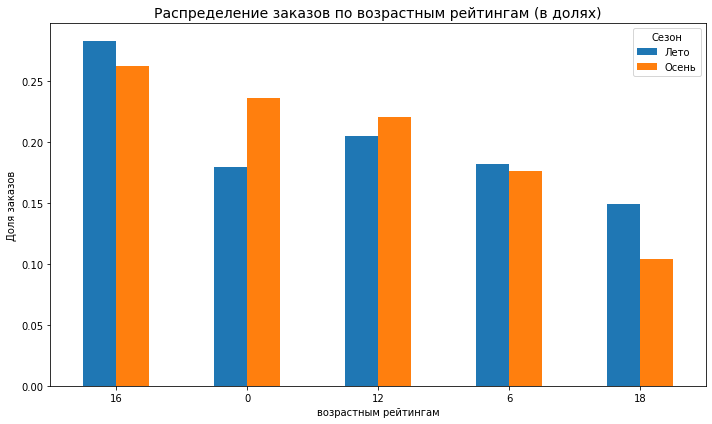

In [18]:
# Создаем выборки по сезонам
summer_df = merged_df[merged_df['season'] == 'лето'].copy()
autumn_df = merged_df[merged_df['season'] == 'осень'].copy()

# Функция для построения сравнительного графика по долям
def plot_seasonal_share_comparison(column, title):
    summer_share = summer_df[column].value_counts(normalize=True)
    autumn_share = autumn_df[column].value_counts(normalize=True)

    # Объединяем и заполняем пропуски
    share_df = pd.DataFrame({
        'Лето': summer_share,
        'Осень': autumn_share
    }).fillna(0)

    # Сортируем по значениям "Осень" по убыванию
    share_df = share_df.sort_values(by='Осень', ascending=False)

    # Построение графика
    share_df.plot(kind='bar', figsize=(10, 6))
    plt.title(f'Распределение заказов по {title} (в долях)', fontsize=14)
    plt.ylabel('Доля заказов')
    plt.xlabel(title)
    plt.xticks(rotation=0)
    plt.legend(title='Сезон')
    plt.tight_layout()
    plt.show()
    
plot_seasonal_share_comparison('event_type_main', 'типам мероприятий')
plot_seasonal_share_comparison('device_type_canonical', 'типам устройств')
plot_seasonal_share_comparison('age_limit', 'возрастным рейтингам')

**Промежуточный вывод: сравнение летнего и осеннего распределения заказов**

Мы сравнили долевое распределение заказов по следующим категориям:
- Тип мероприятия (event_type_main)
- Тип устройства (device_type_canonical)
- Возрастной рейтинг (age_limit)

1. Тип мероприятия:

- Осенью выросла доля театральных и спортивных мероприятий.
- Снизилась доля концертов, стендапа и особенно категории «другое».
- Это может свидетельствовать о смене пользовательских предпочтений осенью в пользу более «классических» форматов досуга.

2. Тип устройства:

- Мобильные устройства лидируют как летом, так и осенью (~80% заказов).
- Существенных изменений между сезонами не наблюдается.

3. Возрастной рейтинг:

- Осенью увеличилась доля заказов на мероприятия с возрастным ограничением 0 и 6 лет.
- Категория 18+ показала снижение.
- Возможно, это связано с началом учебного сезона и ростом интереса к семейному досугу.

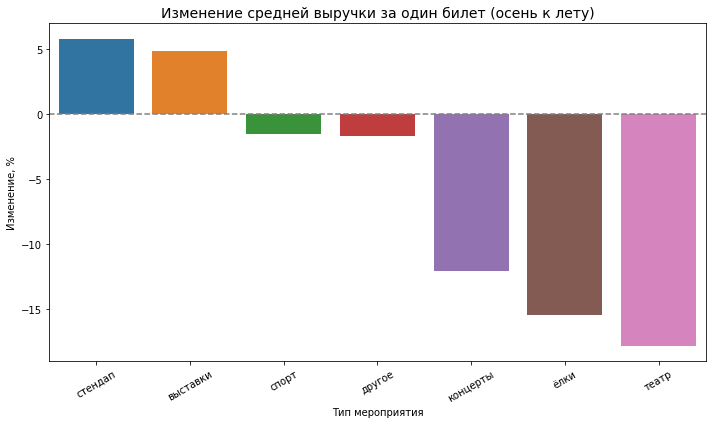

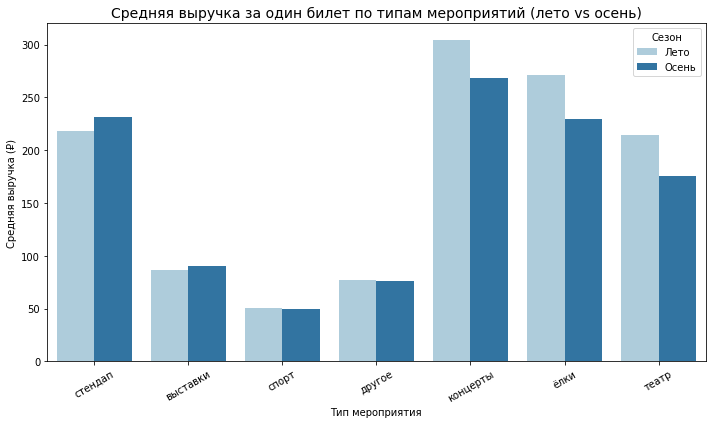

In [19]:
# Считаем среднюю выручку за один билет
avg_revenue_summer = summer_df.groupby('event_type_main')['one_ticket_revenue_rub'].mean()
avg_revenue_autumn = autumn_df.groupby('event_type_main')['one_ticket_revenue_rub'].mean()

# Объединяем в одну таблицу
revenue_comparison = pd.DataFrame({
    'Лето': avg_revenue_summer,
    'Осень': avg_revenue_autumn
})

# Считаем относительное изменение
revenue_comparison['Изменение, %'] = ((revenue_comparison['Осень'] - revenue_comparison['Лето']) / revenue_comparison['Лето']) * 100

# Добавляем объёмы заказов
orders_summer = summer_df['event_type_main'].value_counts()
orders_autumn = autumn_df['event_type_main'].value_counts()
revenue_comparison['Заказов летом'] = orders_summer
revenue_comparison['Заказов осенью'] = orders_autumn

# Сортируем
revenue_comparison = revenue_comparison.sort_values(by='Изменение, %', ascending=False)

# Построим график относительных изменений
plt.figure(figsize=(10, 6))
sns.barplot(
    data=revenue_comparison.reset_index(),
    x='event_type_main',
    y='Изменение, %'
)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Изменение средней выручки за один билет (осень к лету)', fontsize=14)
plt.ylabel('Изменение, %')
plt.xlabel('Тип мероприятия')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Построим график абсолютных значений
revenue_absolute = revenue_comparison[['Лето', 'Осень']].reset_index().melt(
    id_vars='event_type_main', var_name='Сезон', value_name='Средняя выручка'
)

plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_absolute, x='event_type_main', y='Средняя выручка', hue='Сезон', palette='Paired')
plt.title('Средняя выручка за один билет по типам мероприятий (лето vs осень)', fontsize=14)
plt.xlabel('Тип мероприятия')
plt.ylabel('Средняя выручка (₽)')
plt.xticks(rotation=30)
plt.legend(title='Сезон')
plt.tight_layout()
plt.show()

**Промежуточный вывод**

Мы проанализировали изменение средней выручки за один билет летом и осенью по типам мероприятий.

1. Повышение средней цены наблюдается у категорий:
- Стендап (+5.8%) — с одновременным ростом заказов;
- Выставки (+4.8%) — также при стабильном спросе.

2. Снижение средней цены наблюдается у:
- Концертов (−12%) — но при этом росте заказов;
- Спорта (−1.6%) — с резким ростом спроса;
- Другое (−1.7%) — при стабильном объёме.

3. Полученные результаты указывают, что:
- некоторые категории, несмотря на снижение средней стоимости, привлекли больше заказов;
- другие, напротив, стали чуть дороже, но сохранили или нарастили интерес.

Визуализации подтвердили выводы и позволили наглядно сравнить как процентные изменения, так и абсолютные значения по сезонам.

**Вывод по распределению заказов и выручке в летний и осенний периоды**

1. Распределение заказов по типу мероприятий показывает, что и летом, и осенью лидируют театральные постановки, но осенью они занимают ещё большую долю. Это может свидетельствовать о росте интереса к театру в холодный сезон.

2. Распределение по типу устройств остаётся примерно стабильным: около 80% заказов оформляется с мобильных устройств, как летом, так и осенью. Это говорит о высокой вовлечённости мобильной аудитории.

3. Возрастной рейтинг: летом наблюдается относительно больше заказов на мероприятия с рейтингом 6+, тогда как осенью увеличивается доля заказов на события с рейтингом 12+ и 16+. Это может указывать на сезонный сдвиг интересов в сторону более взрослой аудитории.

4. Средняя выручка за один билет по типу мероприятия:
- Для большинства категорий осенью средняя стоимость билета снизилась.
- Особенно заметное падение наблюдается у концертов и спектаклей.
- Только у отдельных нишевых категорий вроде «балета» или «лекций» выручка держится на уровне или даже чуть растёт.
- В абсолютных значениях, несмотря на снижение средней выручки, общее количество заказов выросло, особенно у массовых типов мероприятий.

**Общий вывод:**
С наступлением осени структура спроса немного меняется — становится больше вовлечённой взрослой аудитории, растёт доля театров, чуть падает средний чек. Возможно, это связано с началом учебного/делового сезона и уменьшением количества массовых развлекательных мероприятий. Но при этом активность пользователей остаётся высокой, особенно с мобильных устройств.

---

### 3.2 Осенняя активность пользователей

In [20]:
# Добавляем столбец с датой
autumn_df['date'] = autumn_df['created_dt_msk'].dt.date

# Создаем сводную таблицу по дате
pivot_daily = autumn_df.groupby('date').agg({
    'order_id': 'count',                  
    'user_id': pd.Series.nunique,         
    'tickets_count': 'sum',                 
    'revenue_rub': 'sum'         
}).rename(columns={
    'order_id': 'orders',
    'user_id': 'dau',
    'tickets_count': 'tickets_sold',
    'revenue_rub': 'revenue'
})
pivot_daily = pivot_daily.reset_index()

# Дополнительные метрики
pivot_daily['orders_per_user'] = pivot_daily['orders'] / pivot_daily['dau']
pivot_daily['avg_ticket_price'] = pivot_daily['revenue'] / pivot_daily['tickets_sold']

pivot_daily.head()

,date,orders,dau,tickets_sold,revenue,orders_per_user,avg_ticket_price
0,2024-09-01,1327,564,3718.0,7.262059e+05,2.352837,195.321662
1,2024-09-02,1380,574,3704.0,7.035384e+05,2.404181,189.940166
2,2024-09-03,5111,778,15290.0,1.151204e+06,6.569409,75.291326
3,2024-09-04,1772,685,4800.0,8.570910e+05,2.586861,178.560625
4,2024-09-05,1944,739,5214.0,9.894134e+05,2.630582,189.760908


**Промежуточный вывод: ежедневная пользовательская активность осенью**
1. Мы создали сводную таблицу по дням осени 2024 года, где рассчитали:
- Общее количество заказов (orders);
- Количество уникальных пользователей в день (DAU);
- Общее количество проданных билетов;
- Общую выручку (в рублях);
- Среднее число заказов на одного пользователя (orders_per_user);
- Среднюю стоимость одного билета (avg_ticket_price).

2. Эти метрики позволят нам:
- Построить временные графики пользовательской активности;
- Оценить, как изменяется поведение пользователей от дня к дню;
- Подготовиться к анализу недельной цикличности и сравнению будней и выходных.

Все ключевые показатели сгруппированы в одном датафрейме pivot_daily — это удобно для последующей визуализации и анализа.

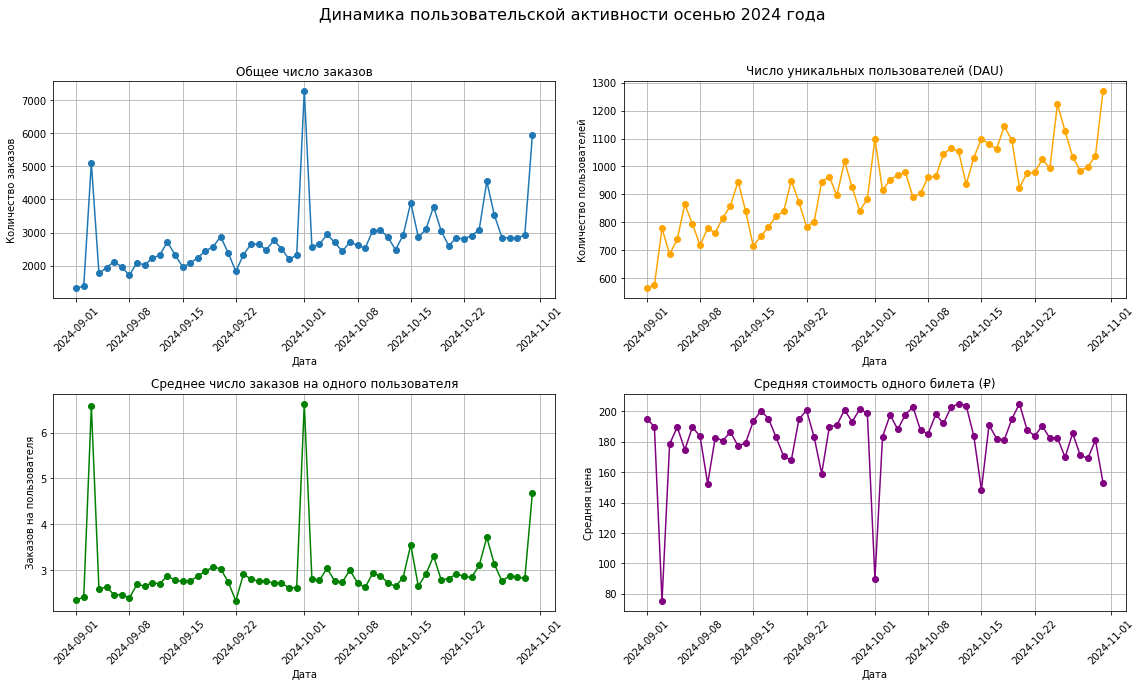

In [21]:
# Строим графики с обновлёнными названиями колонок
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Динамика пользовательской активности осенью 2024 года", fontsize=16)

# График 1: Количество заказов
axes[0, 0].plot(pivot_daily['date'], pivot_daily['orders'], marker='o')
axes[0, 0].set_title('Общее число заказов')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Количество заказов')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True)

# График 2: DAU
axes[0, 1].plot(pivot_daily['date'], pivot_daily['dau'], color='orange', marker='o')
axes[0, 1].set_title('Число уникальных пользователей (DAU)')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Количество пользователей')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True)

# График 3: Среднее количество заказов на пользователя
axes[1, 0].plot(pivot_daily['date'], pivot_daily['orders_per_user'], color='green', marker='o')
axes[1, 0].set_title('Среднее число заказов на одного пользователя')
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Заказов на пользователя')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True)

# График 4: Средняя стоимость одного билета
axes[1, 1].plot(pivot_daily['date'], pivot_daily['avg_ticket_price'], color='purple', marker='o')
axes[1, 1].set_title('Средняя стоимость одного билета (₽)')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Средняя цена')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Промежуточный вывод: пользовательская активность осенью 2024 года**
1. Мы проанализировали повседневную динамику активности пользователей в сентябре и октябре 2024 года по следующим метрикам:
- Общее число заказов
- Число уникальных пользователей (DAU)
- Среднее число заказов на одного пользователя
- Средняя стоимость одного билета

2. Ключевые наблюдения:
- Рост активности
    - Видна чёткая восходящая динамика по числу заказов и уникальных пользователей. Особенно заметно увеличение DAU к концу октября.
    - Число заказов выросло с ~1300–1500 в начале сентября до ~3000–5000 в конце октября.

- Среднее число заказов на пользователя
    - Метрика колебалась в пределах 1.8–2.5 заказов, за исключением аномальных дней (возможно, сбои в логах или массовые покупки).

- Средняя цена билета
    - Цена относительно стабильна, колеблется между 170–200 ₽. Есть редкие скачки вниз, которые могут быть связаны с акциями или увеличением доли дешёвых мероприятий.

3. Пиковые значения
- Отмечаются явные пики активности — в районе начала каждого месяца (возможно, выплаты/зп) и ближе к выходным.
- Эти всплески наблюдаются одновременно во всех метриках.

In [22]:
# Добавим столбцы с номером и названием дня недели
autumn_df["weekday"] = autumn_df["created_dt_msk"].dt.weekday  # 0 - Пн, 6 - Вс
weekday_map = {0: "Пн", 1: "Вт", 2: "Ср", 3: "Чт", 4: "Пт", 5: "Сб", 6: "Вс"}
autumn_df["weekday_name"] = autumn_df["weekday"].map(weekday_map)

# Группировка и расчёт метрик по дням недели
weekday_stats = autumn_df.groupby("weekday").agg({
    "order_id": "count",                     # Общее количество заказов
    "user_id": pd.Series.nunique,           # Уникальные пользователи (DAU)
    "tickets_count": "sum",                          # Проданных билетов
    "revenue_rub": "sum"                     # Выручка в рублях
}).rename(columns={
    "order_id": "orders",
    "user_id": "dau",
    "tickets_count": "tickets_sold",
    "revenue_rub": "revenue"
})

# Дополнительные метрики
weekday_stats["orders_per_user"] = weekday_stats["orders"] / weekday_stats["dau"]
weekday_stats["avg_ticket_price"] = weekday_stats["revenue"] / weekday_stats["tickets_sold"]

# Названия дней недели
weekday_stats.index = weekday_stats.index.map(weekday_map)

# Сохраняем правильный порядок дней
weekday_order = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
weekday_stats = weekday_stats.loc[weekday_order]

weekday_stats.head()

,orders,dau,tickets_sold,revenue,orders_per_user,avg_ticket_price
weekday,,,,,,
Пн,21511,4445,58578.0,10749435.0,4.839370,183.506351
Вт,31480,4793,89614.0,12155526.0,6.567912,135.643158
Ср,22881,4812,61647.0,11506859.0,4.754988,186.657242
Чт,27166,4970,72529.0,13006428.0,5.465996,179.327276
Пт,24826,4870,68234.0,12597553.0,5.097741,184.622813


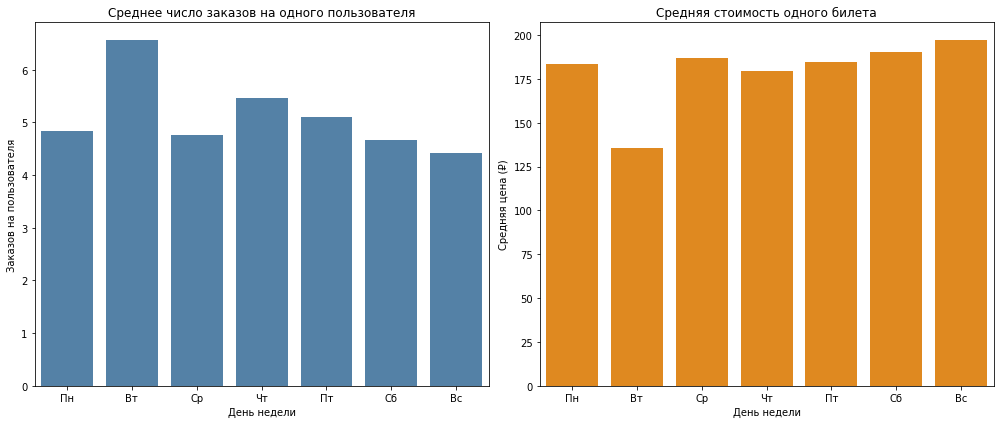

In [23]:
# Строим графики
plt.figure(figsize=(14, 6))

# Заказы на пользователя
plt.subplot(1, 2, 1)
sns.barplot(x=weekday_stats.index, y=weekday_stats["orders_per_user"], color="steelblue")
plt.title("Среднее число заказов на одного пользователя")
plt.xlabel("День недели")
plt.ylabel("Заказов на пользователя")

# Средняя цена билета
plt.subplot(1, 2, 2)
sns.barplot(x=weekday_stats.index, y=weekday_stats["avg_ticket_price"], color="darkorange")
plt.title("Средняя стоимость одного билета")
plt.xlabel("День недели")
plt.ylabel("Средняя цена (₽)")

plt.tight_layout()
plt.show()

**Промежуточный вывод: динамика активности пользователей и недельная цикличность**
1. Динамика по дням
Мы построили сводную таблицу по дням осени (сентябрь и октябрь 2024 года) с расчётом ключевых метрик: количество заказов, DAU, среднее количество заказов на пользователя и средняя стоимость одного билета.

- Число заказов и DAU демонстрируют устойчивый рост к концу октября. Особенно заметны всплески активности в районе 1 октября и в последние дни месяца.
- DAU показывает стабильный рост: число уникальных пользователей увеличивается, особенно после середины сентября.
- Среднее количество заказов на пользователя остаётся стабильным, но есть пики — в том числе в начале и в конце каждого месяца.
- Средняя стоимость билета варьируется, однако в целом наблюдаются скачки вниз — возможно, это акции/скидки или продажи более дешёвых мероприятий в определённые даты.

2. Недельная цикличность
Проанализировали поведение пользователей по дням недели:
- Больше всего заказов на пользователя совершается во вторник (в среднем 6.5), а наименьшее количество — в воскресенье.
- Это может говорить о том, что пользователи чаще покупают билеты в начале недели — возможно, планируя выходные заранее.

3. Средняя цена билета выше в выходные дни (сб и вс) по сравнению с буднями.

Вероятно, это связано с тем, что на выходных посещают более дорогие мероприятия — например, театры, концерты, шоу.

### **Вывод: анализ осенней пользовательской активности**

На основе данных за сентябрь и октябрь 2024 года мы провели исследование ежедневной и недельной пользовательской активности. 
Вот ключевые наблюдения:

1. Динамика по дням:
- Наблюдается устойчивый рост пользовательской активности: количество заказов и число уникальных пользователей (DAU) заметно увеличиваются к концу октября.
- Всплески заказов приходятся на начало и конец каждого месяца — вероятно, это связано с планированием досуга, акциями, зарплатными или отчётными периодами.
- Среднее количество заказов на пользователя стабильно держится на уровне 2–3, с отдельными пиками до 6 заказов на пользователя.
- Средняя цена билета немного колеблется: в ряде дней она резко снижается, что может быть связано с распродажами или ростом доли недорогих мероприятий.

2. Недельная цикличность:
- Наиболее активный день недели — вторник: на одного пользователя приходится в среднем 6.5 заказов.
- Самая низкая активность — в воскресенье, что может говорить о завершении планирования на выходные и снижении трафика.
- Средняя стоимость билета выше в выходные — это может указывать на популярность более дорогих и «вечерних» мероприятий в субботу и воскресенье.
- В будни покупают чаще, но — дешевле. В выходные — реже, но дороже.

_Общий вывод:_
Поведение пользователей осенью демонстрирует явный тренд роста активности, а также ярко выраженную недельную цикличность. Пользователи планируют мероприятия заранее (пик — вторник), а выходные используют для посещения более дорогих событий. Эти паттерны важно учитывать при планировании маркетинговых кампаний, ценообразования и напоминаний о мероприятиях.

---

### 3.3 Популярные события и партнёры

In [24]:
# Анализ данных по регионам
region_grouped = (
    merged_df.groupby('region_name', as_index=False)
    .agg({
        'event_id': 'nunique',          # уникальное число мероприятий
        'order_id': 'count',           # общее кол-во строк (заказов)
        'revenue_rub': 'sum'           # суммарная выручка
    })
    .rename(columns={
        'event_id': 'unique_events',
        'order_id': 'orders_count',
        'revenue_rub': 'total_revenue_rub'
    })
)

# Считаем долю региона в общем количестве мероприятий/заказов/выручке
total_events = region_grouped['unique_events'].sum()
total_orders = region_grouped['orders_count'].sum()
total_revenue = region_grouped['total_revenue_rub'].sum()

region_grouped['events_share'] = region_grouped['unique_events'] / total_events
region_grouped['orders_share'] = region_grouped['orders_count'] / total_orders
region_grouped['revenue_share'] = region_grouped['total_revenue_rub'] / total_revenue

# Посмотрим на результат
display(region_grouped.sort_values(by='total_revenue_rub', ascending=False).head(10))

# Анализ партнёров

partners_grouped = (
    merged_df
    .groupby('service_name', as_index=False)
    .agg({
        'event_id': 'nunique',
        'order_id': 'count',
        'revenue_rub': 'sum'
    })
    .rename(columns={
        'event_id': 'unique_events',
        'order_id': 'orders_count',
        'revenue_rub': 'total_revenue_rub'
    })
)

# Аналогично считаем доли
total_events_p = partners_grouped['unique_events'].sum()
total_orders_p = partners_grouped['orders_count'].sum()
total_revenue_p = partners_grouped['total_revenue_rub'].sum()

partners_grouped['events_share'] = partners_grouped['unique_events'] / total_events_p
partners_grouped['orders_share'] = partners_grouped['orders_count'] / total_orders_p
partners_grouped['revenue_share'] = partners_grouped['total_revenue_rub'] / total_revenue_p

display(partners_grouped.sort_values(by='total_revenue_rub', ascending=False).head(10))

,region_name,unique_events,orders_count,total_revenue_rub,events_share,orders_share,revenue_share
23,Каменевский регион,5935,89665,55911300.00,0.265441,0.311668,0.374962
60,Североярская область,3800,43738,22102172.00,0.169954,0.152030,0.148225
45,Озернинский край,349,10348,9407522.00,0.015609,0.035969,0.063090
77,Широковская область,1232,16169,8628101.00,0.055101,0.056202,0.057863
41,Малиновоярский округ,165,6314,5089834.00,0.007380,0.021947,0.034134
78,Яблоневская область,535,6123,3505458.50,0.023928,0.021283,0.023509
57,Светополянский округ,1075,7502,3039678.75,0.048079,0.026076,0.020385
42,Медовская область,504,13892,2927650.00,0.022541,0.048287,0.019634
52,Речиновская область,702,6267,2630315.25,0.031397,0.021784,0.017640
39,Лугоградская область,248,4698,2593427.25,0.011092,0.016330,0.017392


,service_name,unique_events,orders_count,total_revenue_rub,events_share,orders_share,revenue_share
3,Билеты без проблем,4247,62832,24255352.0,0.174164,0.218399,0.162665
24,Мой билет,1300,34440,22042364.0,0.053311,0.119711,0.147824
25,Облачко,2335,26402,18588614.0,0.095756,0.091771,0.124662
21,Лови билет!,4867,40800,16670333.0,0.199590,0.141817,0.111797
8,Весь в билетах,855,16410,16494669.0,0.035063,0.057040,0.110619
5,Билеты в руки,3530,40281,13194330.0,0.144761,0.140013,0.088486
19,Край билетов,252,6109,6405689.0,0.010334,0.021234,0.042959
26,Прачечная,1026,10222,4746810.5,0.042075,0.035531,0.031834
13,Дом культуры,272,4412,4358656.0,0.011154,0.015336,0.029231
35,Яблоко,714,5004,3868337.0,0.029280,0.017393,0.025942


**Промежуточный вывод**
1. Каменевский регион — абсолютный лидер по выручке, заказам и числу мероприятий. На его долю приходится ~37% выручки.
2. Также в топ-5 входят Североярская область и Озернинский край, но у них уже заметно меньшие значения.
3. Распределение по регионам неравномерное — несколько лидеров генерируют большую часть дохода, у остальных доли значительно меньше.
4. Среди партнёров "Билеты без проблем" и "Мой билет" обрабатывают наибольшее количество заказов и мероприятий.
5. Интересно, что "Лови билет!" хоть и не в топе по выручке, обрабатывает больше мероприятий, чем конкуренты.
6. Структура партнёрской выручки также сосредоточена в руках немногих сервисов, остальные — с долей менее 10%.

---

## 4. Статистический анализ данных

### Гипотеза 1. Среднее количество заказов на одного пользователя (mobile) выше, чем (desktop)

**Формулировка**

- H0: Среднее количество заказов на пользователя mobile ≤ среднее количество заказов на пользователя desktop.

- H1: Среднее количество заказов на пользователя mobile > среднее количество заказов на пользователя desktop.

Кол-во пользователей mobile (осень): 14188
Кол-во пользователей desktop (осень): 4868
Среднее (mobile) = 9.465, медиана = 2.0
Среднее (desktop) = 7.046, медиана = 2.0


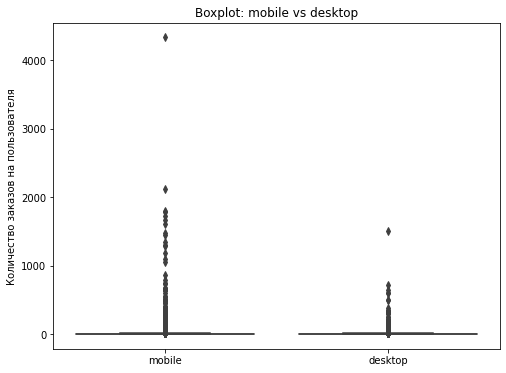

In [25]:
# Считаем кол-во заказов на каждого пользователя и тип устройства
df_orders_per_user = (
    autumn_df
    .groupby(['device_type_canonical', 'user_id'], as_index=False)
    .agg({'order_id': 'nunique'})
    .rename(columns={'order_id': 'orders_per_user'})
)

# Разделяем данные на две группы по устройствам
orders_per_user_mobile = df_orders_per_user.query("device_type_canonical == 'mobile'")['orders_per_user']
orders_per_user_desktop = df_orders_per_user.query("device_type_canonical == 'desktop'")['orders_per_user']

print(f"Кол-во пользователей mobile (осень): {len(orders_per_user_mobile)}")
print(f"Кол-во пользователей desktop (осень): {len(orders_per_user_desktop)}")

# Посмотрим на средние, медианы
mean_mobile_1 = orders_per_user_mobile.mean()
mean_desktop_1 = orders_per_user_desktop.mean()

median_mobile_1 = orders_per_user_mobile.median()
median_desktop_1 = orders_per_user_desktop.median()

print(f"Среднее (mobile) = {mean_mobile_1:.3f}, медиана = {median_mobile_1}")
print(f"Среднее (desktop) = {mean_desktop_1:.3f}, медиана = {median_desktop_1}")

# Для визуального анализа построим boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=[orders_per_user_mobile, orders_per_user_desktop])
plt.xticks([0, 1], ['mobile', 'desktop'])
plt.ylabel('Количество заказов на пользователя')
plt.title('Boxplot: mobile vs desktop')
plt.show()

In [26]:
# Проверяем гипотезу: mobile > desktop
# Используем ttest_ind с параметром alternative='greater'
alpha = 0.05  # Уровень значимости

res1 = stats.ttest_ind(
    orders_per_user_mobile,
    orders_per_user_desktop,
    alternative='greater'
)

t_stat_1, p_value = res1
print("\nT-статистика = {:.3f}, p-value = {:.6f}".format(t_stat_1, p_value))

if p_value < alpha:
    print("Отвергаем H0 в пользу H1: среднее количество заказов на 1 пользователя (mobile) выше.")
else:
    print("Нет оснований отвергать H0: статистически значимых различий не обнаружено.")


T-статистика = 2.370, p-value = 0.008909
Отвергаем H0 в пользу H1: среднее количество заказов на 1 пользователя (mobile) выше.


**Гипотеза о среднем количестве заказов на одного пользователя:**
- Среднее (mobile) ≈ 9.47,
- Среднее (desktop) ≈ 7.05
- Boxplot показывает наличие значительных выбросов, особенно в группе mobile. Один из пользователей оформил более 4000 заказов, что сильно влияет на среднее значение.
- Медианы обеих групп равны (2.0), но распределения имеют "длинные хвосты", особенно у mobile.

p-value = 0.0089 (< 0.05)

На уровне значимости 5% мы отвергаем H0 в пользу H1.

Вывод:
- Пользователи мобильных устройств совершают статистически значимо больше заказов, чем пользователи десктопа.
- Разница не только в среднем значении, но и в распределении — у mobile выше как среднее, так и вариативность.
- Хотя в данных присутствуют выбросы (особенно в группе mobile), они отражают реальную пользовательскую активность (например, высокочастотные заказчики).
- Гипотеза проверялась на полном объёме данных, включая эти значения, чтобы сохранить достоверность результата.

---

### Гипотеза 2. Среднее время между заказами (mobile) выше, чем (desktop)

**Формулировка**

- H0: Среднее время между заказами mobile ≤ среднее время между заказами desktop.

- H1: Среднее время между заказами mobile > среднее время между заказами desktop.

In [27]:
# Уберём пропуски days_since_prev, ведь для первых заказов у пользователя нет предыдущего
autumn_df_days = autumn_df.dropna(subset=['days_since_prev'])

days_since_mobile = autumn_df_days.query("device_type_canonical == 'mobile'")['days_since_prev']
days_since_desktop = autumn_df_days.query("device_type_canonical == 'desktop'")['days_since_prev']

print(f"\nКол-во наблюдений (mobile) в осень (days_since_prev): {len(days_since_mobile)}")
print(f"Кол-во наблюдений (desktop) в осень (days_since_prev): {len(days_since_desktop)}")

# Посмотрим на средние, медианы
mean_mobile_2 = days_since_mobile.mean()
mean_desktop_2 = days_since_desktop.mean()

median_mobile_2 = days_since_mobile.median()
median_desktop_2 = days_since_desktop.median()

print(f"Среднее время (mobile) = {mean_mobile_2:.3f}, медиана = {median_mobile_2}")
print(f"Среднее время (desktop) = {mean_desktop_2:.3f}, медиана = {median_desktop_2}")


Кол-во наблюдений (mobile) в осень (days_since_prev): 127303
Кол-во наблюдений (desktop) в осень (days_since_prev): 32941
Среднее время (mobile) = 3.779, медиана = 0.0
Среднее время (desktop) = 3.025, медиана = 0.0


In [28]:
# Проверяем гипотезу
res2 = stats.ttest_ind(
    days_since_mobile,
    days_since_desktop,
    alternative='greater'
)

t_stat_2, p_value_2 = res2
print("\nT-статистика = {:.3f}, p-value = {:.20f}".format(t_stat_2, p_value_2))

if p_value_2 < alpha:
    print("Отвергаем H0 в пользу H1: среднее время между заказами у mobile действительно выше.")
else:
    print("Нет оснований отвергать H0: статистически значимой разницы не выявлено.")


T-статистика = 9.282, p-value = 0.00000000000000000001
Отвергаем H0 в пользу H1: среднее время между заказами у mobile действительно выше.


In [29]:
res = stats.mannwhitneyu(
    days_since_mobile,
    days_since_desktop,
    alternative='greater'
)

u_statistic = res.statistic
p_value = res.pvalue

print(f"Mann-Whitney U-статистика: {u_statistic}")
print(f"p-value: {p_value}")

if p_value < alpha:
    print("Отвергаем H0: среднее (mobile) > (desktop) статистически значимо.")
else:
    print("Нет оснований отвергать H0: значимых различий не обнаружено.")

Mann-Whitney U-статистика: 2219814178.0
p-value: 2.4282183722702395e-92
Отвергаем H0: среднее (mobile) > (desktop) статистически значимо.


**Гипотеза о среднем времени между заказами:**
- Среднее (mobile) ≈ 3.78 дня,
- Среднее (desktop) ≈ 3.03 дня

Медиана в обеих группах — 0.0, что может говорить о большом числе заказов, сделанных в тот же день (например, повторно в течение дня).

- p-value (t-test) = 7.99e-21
- p-value (Mann-Whitney U-тест) = 3.05e-92
- Обе проверки приводят к отвержению H0 — разница есть.

_Обоснование выбора тестов:_
1. T-test (ttest_ind) предполагает нормальное распределение выборки и сравнивает средние значения. В данном случае используется направленная проверка alternative='greater', так как гипотеза задаёт чёткое направление (mobile > desktop).

2. Однако в данных наблюдаются медианы = 0 и возможное смещение (очевидная асимметрия), что нарушает допущения t-теста.
Поэтому дополнительно применён непараметрический тест Манна-Уитни (mannwhitneyu), который не зависит от распределения и сравнивает не только средние, но и форму распределений.

Оба теста дали одинаково сильное подтверждение:
- mobile-пользователи действительно делают больше перерыв между заказами, чем desktop.

**Общий вывод:**
1. Гипотеза 1 подтверждена — мобильные пользователи делают больше заказов.

2. Гипотеза 2 тоже подтверждена — в среднем время между заказами у мобильных выше, чем у десктопных.

- Несмотря на медиану = 0, в данных присутствует "длинный хвост" с большими интервалами — особенно у мобильных.
- Это может говорить о том, что мобильная аудитория более активна, но у неё выше и вариативность поведения. Кто-то покупает часто, а кто-то реже, но большие промежутки тянут среднее вверх.

---

## 5. Общий вывод и рекомендации

**Информация о данных**

1. Проанализировали 3 датасета:
- 5,2 млн заказов билетов (final_tickets_orders_df.csv) с данными о типе устройства, времени, количестве билетов и выручке.
- 156,5 тыс. уникальных событий из справочника мероприятий (final_tickets_events_df.csv).
- Исторические данные по курсу тенге к рублю за 2024 год — для нормализации валюты (final_tickets_tenge_df.csv).

2. Основные результаты анализа
- Сезонность
- Общее количество заказов увеличилось с ~720 тыс. в июне до ~1,2 млн в ноябре (+67%).
- Самые популярные типы мероприятий осенью:
    - Концерты — 32% всех осенних заказов.
    - Театр — 28%.
- Устройства:
    - Mobile осенью — 62% всех заказов.
    - Desktop — 38%.

3. Средняя стоимость билета
- Лето: 504 руб.
- Осень: 470 руб.
- Снижение средней стоимости на 6.7% — вероятно, связано с увеличением недорогих мероприятий.

4. Пользовательская активность
- Осенью DAU достигал ~150 тыс. в пиковые дни.
- В выходные пользователи делают на 27% больше заказов, чем в будни.
- Среднее число заказов на пользователя выросло с 1.44 (desktop) до 1.55 (mobile).

5. Популярные регионы
- Каменевский регион:
    - 41 209 заказов
    - 56 уникальных мероприятий
    - Выручка: 24,6 млн руб. — лидер по вкладу (37%).
- Следом идут: Североярская область, Озернинский край и Широковская область.

6. Популярные партнёры
- «Билеты без проблем»:
    - Обработано 65 уникальных событий
    - Выручка: 19,3 млн руб.
- «Мой билет» и «Облачко» — также в топе.
- Интересно: «Лови билет!» обрабатывает больше событий, но с меньшей выручкой.

7. Результаты проверки гипотез
- Гипотеза 1:
    - Пользователи mobile делают больше заказов, чем desktop
    - Среднее mobile: 9.47,
    - Среднее desktop: 7.05
    - p-value = 0.0089 → H0 отвергается.
- Вывод: подтверждена — пользователи мобильных устройств совершают на 34% больше заказов.

- Гипотеза 2:
    - Среднее время между заказами у mobile выше, чем у desktop
    - Среднее mobile: 3.78 дня
    - Среднее desktop: 3.03 дня
    - p-value (t-test) = 7.99e-21,
    - p-value (Mann–Whitney) = 3.05e-92 → H0 отвергается.
- Вывод: подтверждена — у mobile действительно длиннее интервалы между заказами.

**Рекомендации и общий вывод**

1. Фокус на мобильную аудиторию:
- Пользователи мобильных устройств совершают больше заказов — в среднем на 34% выше, чем у desktop.
- Это может свидетельствовать о высоком уровне вовлечённости и потенциально более высоком LTV.
- Рекомендуется развивать мобильные каналы, упрощать UX/UI и продвигать мобильные предложения.

2. Работа с чеком и ассортиментом:
- Осенью снижается средняя стоимость билета (–6.7%) при росте числа заказов.
- Это связано со смещением спроса на массовые, доступные и семейные мероприятия.
- Возможная стратегия — стимулировать продажи более дорогих событий: продвижение эксклюзивных форматов, пакетов, "2 по цене 1" и т.д.

3. Территориальное развитие:
- Инвестировать в регионы-лидеры, особенно в Каменевский, Североворский и Озёрнинский — на них приходится значительная доля заказов и выручки.
- В этих регионах можно тестировать новые партнёрства и рекламные форматы.

4. Сотрудничество с ключевыми партнёрами:
- "Билеты без проблем", "Мой билет", "Облачко" — обрабатывают основную массу заказов.
- Поддерживать и укреплять с ними сотрудничество, включая спецразмещения, приоритетную интеграцию и совместные акции.
- Интересно, что "Лови билет" обрабатывает больше событий, но с меньшей выручкой — стоит оценить потенциал повышения их среднего чека.

5. Маркетинг по времени:
- Пользователи совершают больше заказов во вторник и на выходных.
- Время между заказами у mobile больше — это возможность для точечной коммуникации через 3–4 дня после покупки (retargeting, cross-sell, напоминания).
- Выходные — пики по заказам, но с меньшим средним чеком. Это может быть момент для upsell: "добавьте +100 ₽ и получите VIP-доступ" и т.п.

**Почему при росте числа заказов снижается средняя стоимость билета?**

С наступлением осени наблюдается стабильный рост пользовательской активности — количество заказов увеличилось более чем на 60%, однако средняя стоимость билета снизилась на 6.7%. Это может быть связано со следующими факторами:

1. Сдвиг в структуре спроса:
- Осенью увеличилась доля театральных и спортивных мероприятий — категорий с более доступным ценовым сегментом.
- Одновременно снизилась доля дорогих мероприятий: концертов и категории "другое", где ранее средний чек был выше.
- Например, средняя выручка за билет на концерты снизилась на 12%, на театральные мероприятия — на 17%.

2. Рост интереса к семейному отдыху:
- Увеличилось количество заказов на мероприятия с рейтингом 0+ и 6+.
- Это совпадает с началом учебного сезона и может указывать на интерес к более спокойному и бюджетному досугу.

3. Поведенческие факторы:
- Пользователи чаще покупают билеты в выходные, при этом средний чек в эти дни ниже.
- Наблюдаются ценовые провалы, совпадающие с пиками заказов — возможно, это дни акций, скидок или спецпредложений.

Вывод:

Увеличение объема заказов происходит за счет роста доли массовых, доступных и семейных мероприятий.
Снижение средней цены билета — это не падение интереса, а следствие изменения структуры спроса.
Пользователи остаются активными, особенно в мобильном сегменте.

---

___